# 🏦 Loan Approval Predictor
### Machine Learning + Streamlit Project

This notebook trains a Logistic Regression model on the Kaggle Loan Approval Prediction dataset and saves the trained pipeline as `loan_model.pkl` for use in `app.py`.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

## 2. Load Dataset

Place `loan_approval_dataset.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Check Dataset Shape

In [3]:
df.shape

(4269, 13)

## 4. Clean Column Names

In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

## 5. Basic Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## 6. Statistical Summary

In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## 7. Check Missing Values

In [7]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

## 8. Check Duplicate Rows

In [8]:
df.duplicated().sum()

0

## 9. Target Distribution

In [9]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

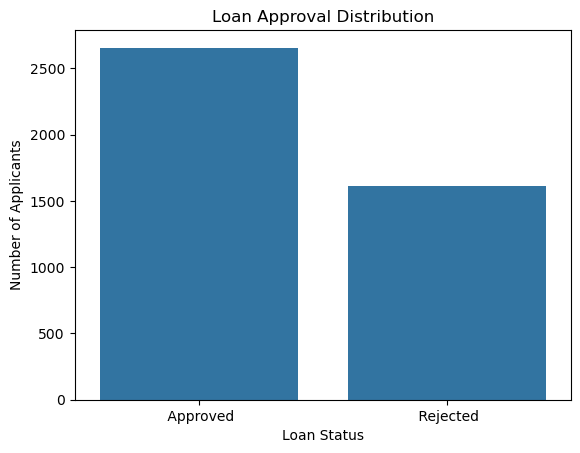

In [10]:
sns.countplot(data=df, x="loan_status")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.show()

## 10. CIBIL Score vs Loan Status

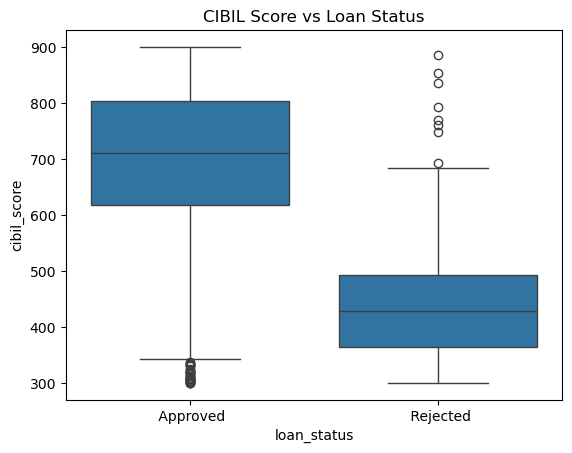

In [11]:
sns.boxplot(data=df, x="loan_status", y="cibil_score")
plt.title("CIBIL Score vs Loan Status")
plt.show()

## 11. Income vs Loan Status

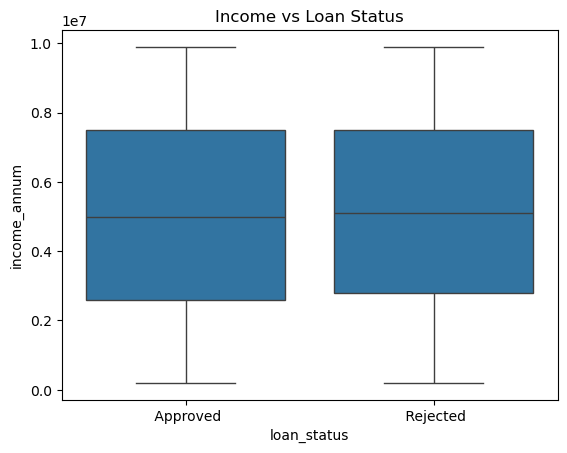

In [12]:
sns.boxplot(data=df, x="loan_status", y="income_annum")
plt.title("Income vs Loan Status")
plt.show()

## 12. Loan Amount vs Loan Status

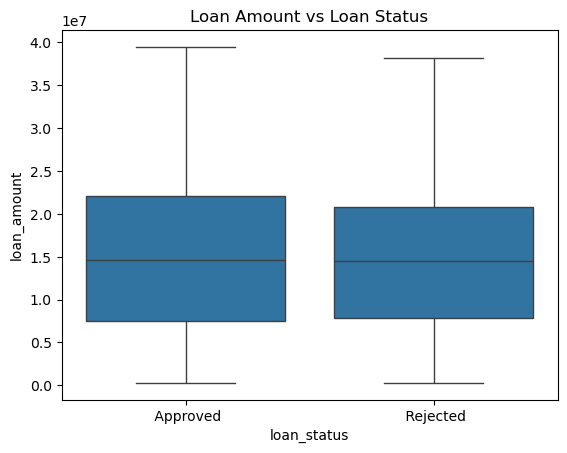

In [13]:
sns.boxplot(data=df, x="loan_status", y="loan_amount")
plt.title("Loan Amount vs Loan Status")
plt.show()

## 13. Education vs Loan Status

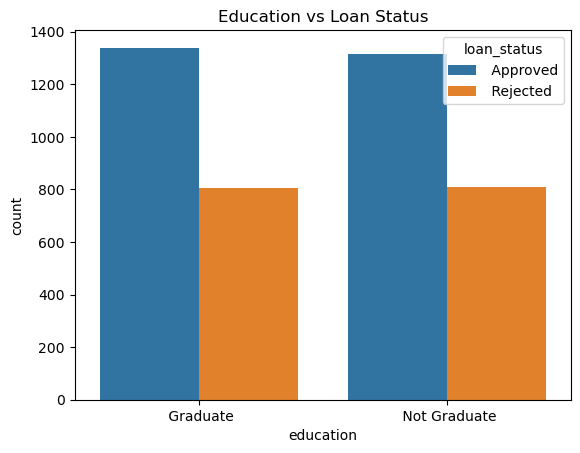

In [14]:
sns.countplot(data=df, x="education", hue="loan_status")
plt.title("Education vs Loan Status")
plt.show()

## 14. Self Employment vs Loan Status

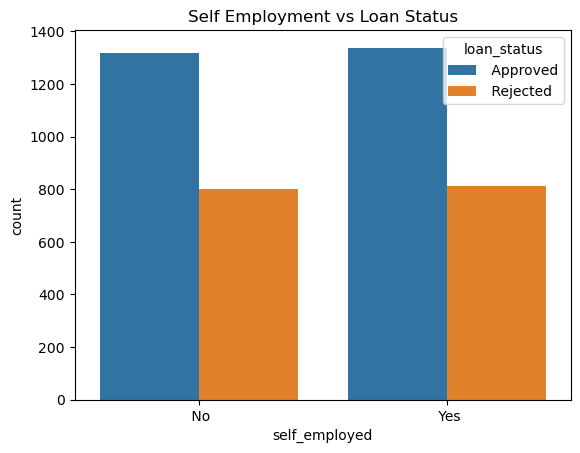

In [15]:
sns.countplot(data=df, x="self_employed", hue="loan_status")
plt.title("Self Employment vs Loan Status")
plt.show()

## 15. Remove Loan ID

`loan_id` is only an identifier and is not useful for predicting loan approval.

In [16]:
df = df.drop("loan_id", axis=1)
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 16. Separate Features and Target

In [17]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Target:
loan_status


## 17. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3415, 11)
X_test: (854, 11)
y_train: (3415,)
y_test: (854,)


## 18. Identify Numerical and Categorical Features

In [19]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Categorical columns:
['education', 'self_employed']


## 19. Create Preprocessing Pipeline

- Numerical features → `StandardScaler`
- Categorical features → `OneHotEncoder`
- `handle_unknown="ignore"` helps prevent errors from unseen categorical values.

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

## 20. Create ML Pipeline

In [21]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression())
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['education', 'self_employed'], dtype='object'))])),
                ('classifier', LogisticRegression())])

## 21. Train the Model

In [22]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['education', 'self_employed'], dtype='object'))])),
                ('classifier', LogisticRegression())])

## 22. Make Predictions

In [23]:
y_pred = model.predict(X_test)
y_pred[:10]

array([' Approved', ' Approved', ' Approved', ' Approved', ' Approved',
       ' Rejected', ' Approved', ' Approved', ' Approved', ' Approved'],
      dtype=object)

## 23. Model Accuracy

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 0.9227
Accuracy: 92.27 %


## 24. Classification Report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



## 25. Confusion Matrix

In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[505  26]
 [ 40 283]]


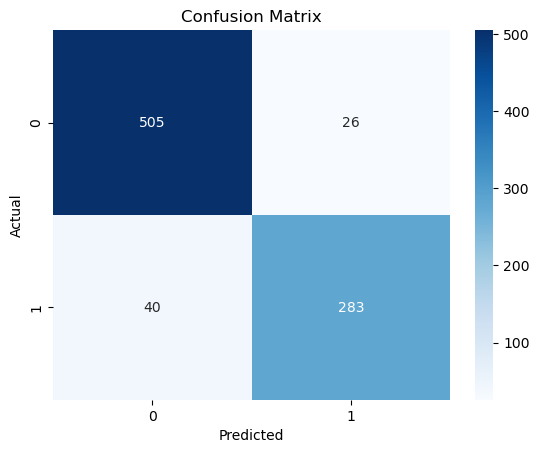

In [27]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 26. Test the Model with a New Applicant

In [28]:
candidate = pd.DataFrame({
    "no_of_dependents": [2],
    "education": ["Graduate"],
    "self_employed": ["No"],
    "income_annum": [500000],
    "loan_amount": [300000],
    "loan_term": [10],
    "cibil_score": [750],
    "residential_assets_value": [500000],
    "commercial_assets_value": [200000],
    "luxury_assets_value": [100000],
    "bank_asset_value": [200000]
})

candidate

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,500000,300000,10,750,500000,200000,100000,200000


## 27. Predict Loan Status

In [29]:
prediction = model.predict(candidate)
print("Prediction:", prediction[0])

Prediction:  Approved


## 28. Prediction Probability

In [30]:
probabilities = model.predict_proba(candidate)[0]
print(probabilities)

[0.99507988 0.00492012]


## 29. Check Class Order

In [31]:
model.classes_

array([' Approved', ' Rejected'], dtype=object)

## 30. Display Approval and Rejection Probability

In [32]:
classes = model.classes_
probability_dict = dict(zip(classes, probabilities))

print(
    "Approval Probability:",
    round(probability_dict.get("Approved", 0) * 100, 2),
    "%"
)

print(
    "Rejection Probability:",
    round(probability_dict.get("Rejected", 0) * 100, 2),
    "%"
)

Approval Probability: 0 %
Rejection Probability: 0 %


## 31. Save the Trained Model

In [33]:
with open("loan_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as loan_model.pkl")

Model saved successfully as loan_model.pkl


## 32. Verify Saved Model

In [34]:
import os
print("loan_model.pkl exists:", os.path.exists("loan_model.pkl"))

loan_model.pkl exists: True


## ✅ Project Output

After running the notebook, your folder should contain:

```text
Loan-Approval-Predictor/
├── loan_approval_dataset.csv
├── loan_approval.ipynb
└── loan_model.pkl
```

The `loan_model.pkl` file is the complete trained preprocessing + Logistic Regression pipeline used by the Streamlit app.